In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("sleppyfish/aircraft-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'aircraft-classification-dataset' dataset.
Path to dataset files: /kaggle/input/aircraft-classification-dataset
Contents of base_path (/kaggle/input):
['aircraft-classification-dataset']
Contents of path (/kaggle/input/aircraft-classification-dataset):
['test', 'train']


### Dataset Overview

Let's examine the structure of the downloaded dataset and display some sample images from the `train` and `test` directories.

In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'test'))}")

Contents of the 'train' directory: ['7', '2', '5', '8', '3', '1', '4', '9', '6']
Contents of the 'test' directory: ['7', '2', '5', '8', '3', '1', '4', '9', '6']


### Displaying Sample Images

Now, let's visualize a few sample images from the 'train' and 'test' datasets to get a better understanding of the image content.


--- Sample Images from Training Dataset (/kaggle/input/aircraft-classification-dataset/train) ---
Found 19569 images in /kaggle/input/aircraft-classification-dataset/train. Displaying 6 samples:


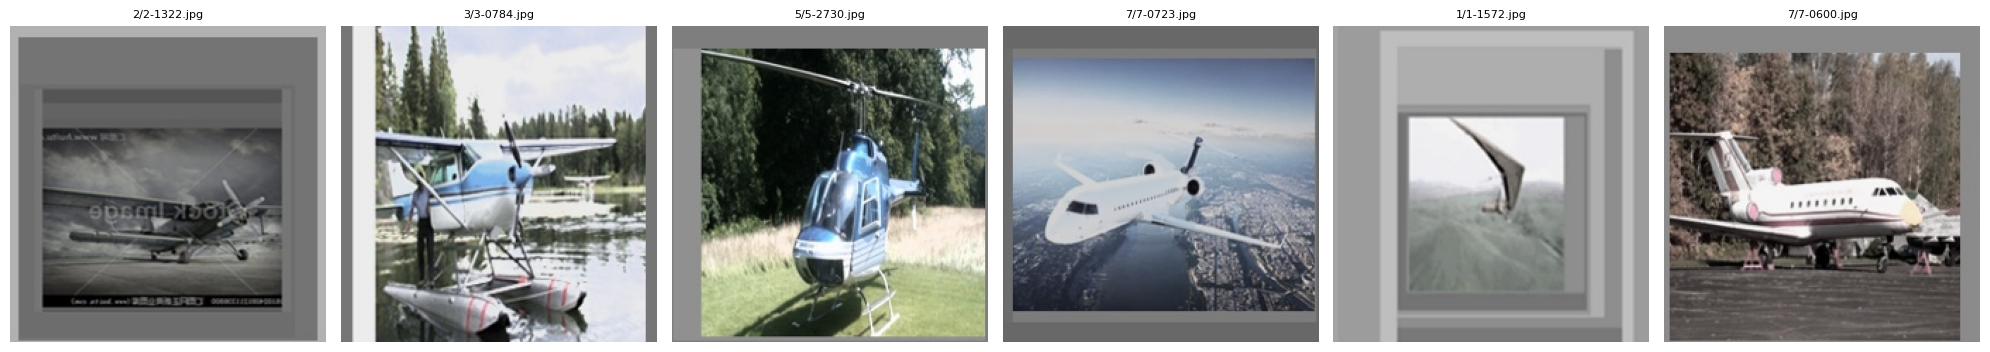


--- Sample Images from Test Dataset (/kaggle/input/aircraft-classification-dataset/test) ---
Found 2305 images in /kaggle/input/aircraft-classification-dataset/test. Displaying 6 samples:


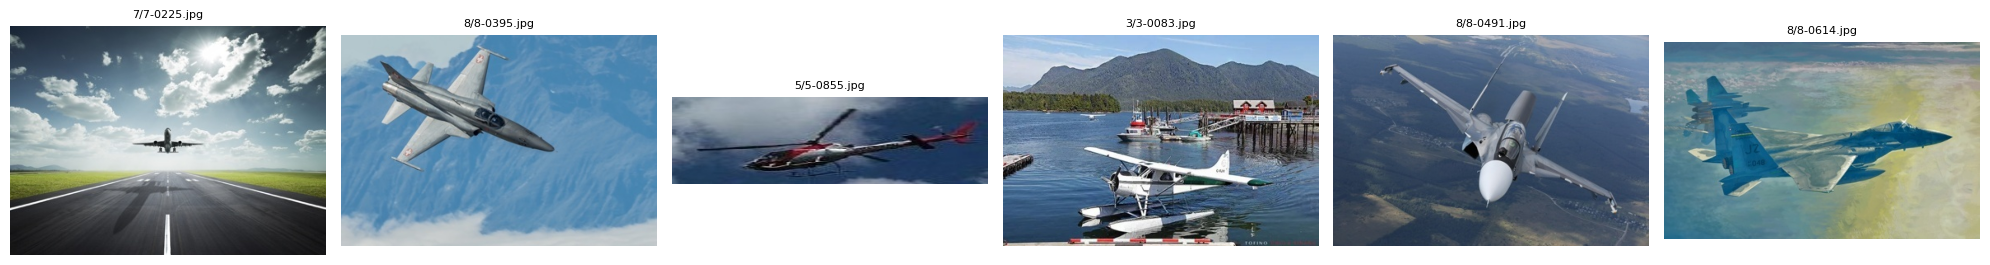

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig) # Close empty figure if no samples
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Display sample images from the 'train' directory
train_path = os.path.join(path, 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

# Display sample images from the 'test' directory
test_path = os.path.join(path, 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

### GPU Availability Check
Before building the model, let's verify if a GPU is available for training.

In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda
Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


### AlexNet Model Architecture and Training
We will now define the AlexNet architecture, prepare the data loaders, and begin the training process.

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Data Augmentation and Normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Define AlexNet
model = models.alexnet(num_classes=len(train_dataset.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
num_epochs = 10
history = {'train_loss': [], 'test_acc': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    history['train_loss'].append(epoch_loss)

    # Simple Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    history['test_acc'].append(accuracy)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch [1/10], Loss: 1.8216, Accuracy: 55.66%
Epoch [2/10], Loss: 1.3018, Accuracy: 70.76%
Epoch [3/10], Loss: 0.9174, Accuracy: 75.14%
Epoch [4/10], Loss: 0.6711, Accuracy: 82.30%
Epoch [5/10], Loss: 0.4669, Accuracy: 86.03%
Epoch [6/10], Loss: 0.3246, Accuracy: 88.89%
Epoch [7/10], Loss: 0.2423, Accuracy: 89.24%
Epoch [8/10], Loss: 0.1887, Accuracy: 90.46%
Epoch [9/10], Loss: 0.1416, Accuracy: 91.71%
Epoch [10/10], Loss: 0.1214, Accuracy: 91.32%


### Training Summary
Let's summarize the final metrics achieved during the session.

In [ ]:
print("--- Training Summary ---")
print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Test Accuracy: {history['test_acc'][-1]:.2f}%")
print(f"Total Epochs: {num_epochs}")

--- Training Summary ---
Final Training Loss: 0.1214
Final Test Accuracy: 91.32%
Total Epochs: 10


### Visualizing Training Progress
The following plots show the decrease in loss and the improvement in accuracy over time.

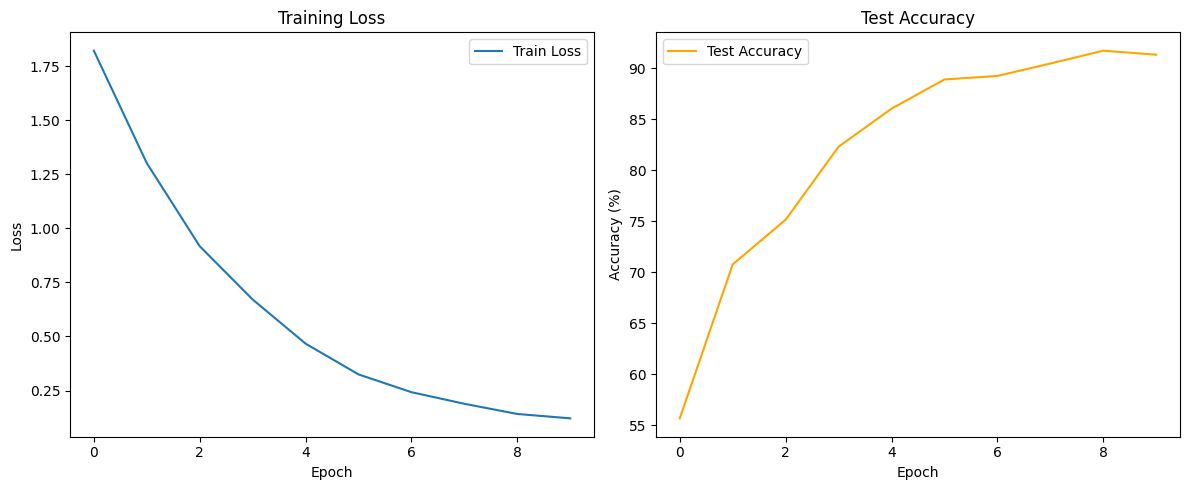

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['test_acc'], label='Test Accuracy', color='orange')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()